# Frame ranges: videos vs annotations vs labels

Are WLASL's clips already cut to the sign, or do the annotated frame ranges matter? And
what do the preprocessed labels actually load, compared with what WLASL annotates?

Three sources are compared, all for `split_name`:

* **Videos**: frame counts of `data/WLASL/WLASL2000/*.mp4`, decoded with OpenCV (the
  same decoder `utils.cv_load` uses), not read from the container header.
* **Annotations**: the raw `frame_start`/`frame_end` in `data/WLASL/splits/<split>.json`
  (1-based, inclusive).
* **Labels**: the preprocessed label files in `labels_dir`. A label loads
  `frames[frame_start:frame_end]`, whatever convention its start was written with.

The findings are summarised in [WLASL_info.md](../../info/WLASL_info.md) (see "Are the
clips pre-cut?" and "Frame-range resets"), which also explains the off-by-one in
labels made before 2026-10-05 (the `*_1_indexed` and `*_cutoff_9` ones).

In [1]:
from multiprocessing import Pool
from pathlib import Path
from typing import Literal, TypeAlias

import pandas as pd
from IPython.display import display
from pydantic import BaseModel, TypeAdapter
from tqdm.auto import tqdm

from src.preprocess import Instance, WLASLClass
from src.results import STASH_DIR_NAME, load_json, stash_json
from src.run_types import AVAIL_SETS, LABELS_PATH, ORIGINAL_SPLITS, RAW_DIR, SPLIT_DIR
from src.utils import (
    decoded_frame_count,
    header_frame_count,
    load_rgb_frames_from_video,
)
from src.video_dataset import (
    LABEL_SUFFIX,
    get_labels_path,
    get_video_path,
    load_data_from_json,
)
from src.visualise2 import (
    FIGSIZE,
    animate_frames,
    animation_html,
    plot_frame_grid,
    plot_stacked_bar_chart,
    set_thesis_style,
)

## Setup

In [2]:
set_thesis_style()

split_name: ORIGINAL_SPLITS = 'asl2000' # every video; the smaller splits are subsets of it
labels_dir = LABELS_PATH / split_name # the 0-based labels; split_name + '_1_indexed' for the old ones
set_names: list[AVAIL_SETS] = ['train', 'val', 'test']
show_video = False # play the example clip below (adds about 1 MB to the saved notebook)
counts_stash_p = Path(STASH_DIR_NAME) / 'frame_counts.json'

## Decoded frame counts

Decoding all 21095 videos takes about 5 minutes, so the counts are stashed. The videos
never change, so the stash never needs recomputing.

In [3]:
class FrameCounts(BaseModel):
    header: int # CAP_PROP_FRAME_COUNT, what preprocess.fix_bad_frame_range uses
    decoded: int # frames utils.cv_load actually returns


counts_adapter = TypeAdapter(dict[str, FrameCounts])


def count_frames(video_ids: list[str]) -> dict[str, FrameCounts]:
    paths = [get_video_path(v, RAW_DIR) for v in video_ids]
    with Pool(4) as pool:
        decoded = list(tqdm(pool.imap(decoded_frame_count, paths, chunksize=64), total=len(paths), desc='decoding'))
    return {
        v: FrameCounts(header=header_frame_count(p), decoded=d)
        for v, p, d in zip(video_ids, paths, decoded)
    }


raw_classes = TypeAdapter(list[WLASLClass]).validate_json((SPLIT_DIR / f'{split_name}.json').read_text())
video_ids = sorted(inst.video_id for cls in raw_classes for inst in cls.instances)
if not counts_stash_p.exists():
    stash_json(counts_adapter.dump_python(count_frames(video_ids)), counts_stash_p)
counts = counts_adapter.validate_python(load_json(counts_stash_p))
print(f'{len(counts)} videos, {sum(c.header != c.decoded for c in counts.values())} where the header count is wrong')

21095 videos, 0 where the header count is wrong


The header count is exact for every video, so `preprocess.fix_bad_frame_range`'s use of
`CAP_PROP_FRAME_COUNT` is safe, and "the clip's frame count" below means either.

## Annotations vs videos: are the clips pre-cut?

Each annotation is compared with its clip (both as 0-based, end-exclusive ranges):

* **whole clip**: the annotation covers every frame, so it changes nothing.
* **outside clip**: the range can't be in the clip (start past its end, or end past it).
  Preprocessing resets these to the whole clip.
* **late start** / **early end** / **both**: the annotation trims frames off the clip.

In [4]:
AnnotationKind: TypeAlias = Literal['whole clip', 'outside clip', 'late start', 'early end', 'both']


def annotated_range(start: int, end: int, num_frames: int) -> tuple[int, int]:
    """WLASL's 1-based inclusive range as a 0-based, end-exclusive one (-1 = the clip's end)."""
    return start - 1, num_frames if end == -1 else end


def annotation_kind(start: int, end: int, num_frames: int) -> AnnotationKind:
    if start >= num_frames or end > num_frames or end <= start:
        return 'outside clip'
    late, early = start > 0, end < num_frames
    if late and early:
        return 'both'
    return 'late start' if late else 'early end' if early else 'whole clip'


rows = []
for cls in raw_classes:
    for inst in cls.instances:
        num_frames = counts[inst.video_id].decoded
        start, end = annotated_range(inst.frame_start, inst.frame_end, num_frames)
        rows.append({
            'video_id': inst.video_id,
            'gloss': cls.gloss,
            'source': inst.source,
            'set': inst.split,
            'clip_frames': num_frames,
            'ann_start': start,
            'ann_end': end,
            'kind': annotation_kind(start, end, num_frames),
        })
ann_df = pd.DataFrame(rows).set_index('video_id')
inside = ann_df['kind'] != 'outside clip'
ann_df['trimmed_start'] = ann_df['ann_start'].where(inside)
ann_df['trimmed_end'] = (ann_df['clip_frames'] - ann_df['ann_end']).where(inside)
ann_df['trimmed'] = ann_df['trimmed_start'] + ann_df['trimmed_end']

ann_df['kind'].value_counts().rename('instances').to_frame()

,instances
kind,
whole clip,20718
outside clip,296
early end,73
late start,7
both,1


Annotations that trim the clip, by source. All but one of the real trims are
`lillybauer`; the exception is `69512` "today" (`aslbrick`, 12 frames). The other sources
are off by a frame or two at the start.

In [5]:
trims = ann_df[ann_df['trimmed'] > 0]
trims.groupby('source')['trimmed'].describe()[['count', 'min', '50%', 'max']].astype(int).sort_values('count', ascending=False)

,count,min,50%,max
source,,,,
lillybauer,74,24,64,108
handspeak,2,1,1,1
aslbrick,1,12,12,12
aslpro,1,1,1,1
asllex,1,2,2,2
signschool,1,1,1,1
spreadthesign,1,2,2,2


Median fraction of the clip annotated: 0.52


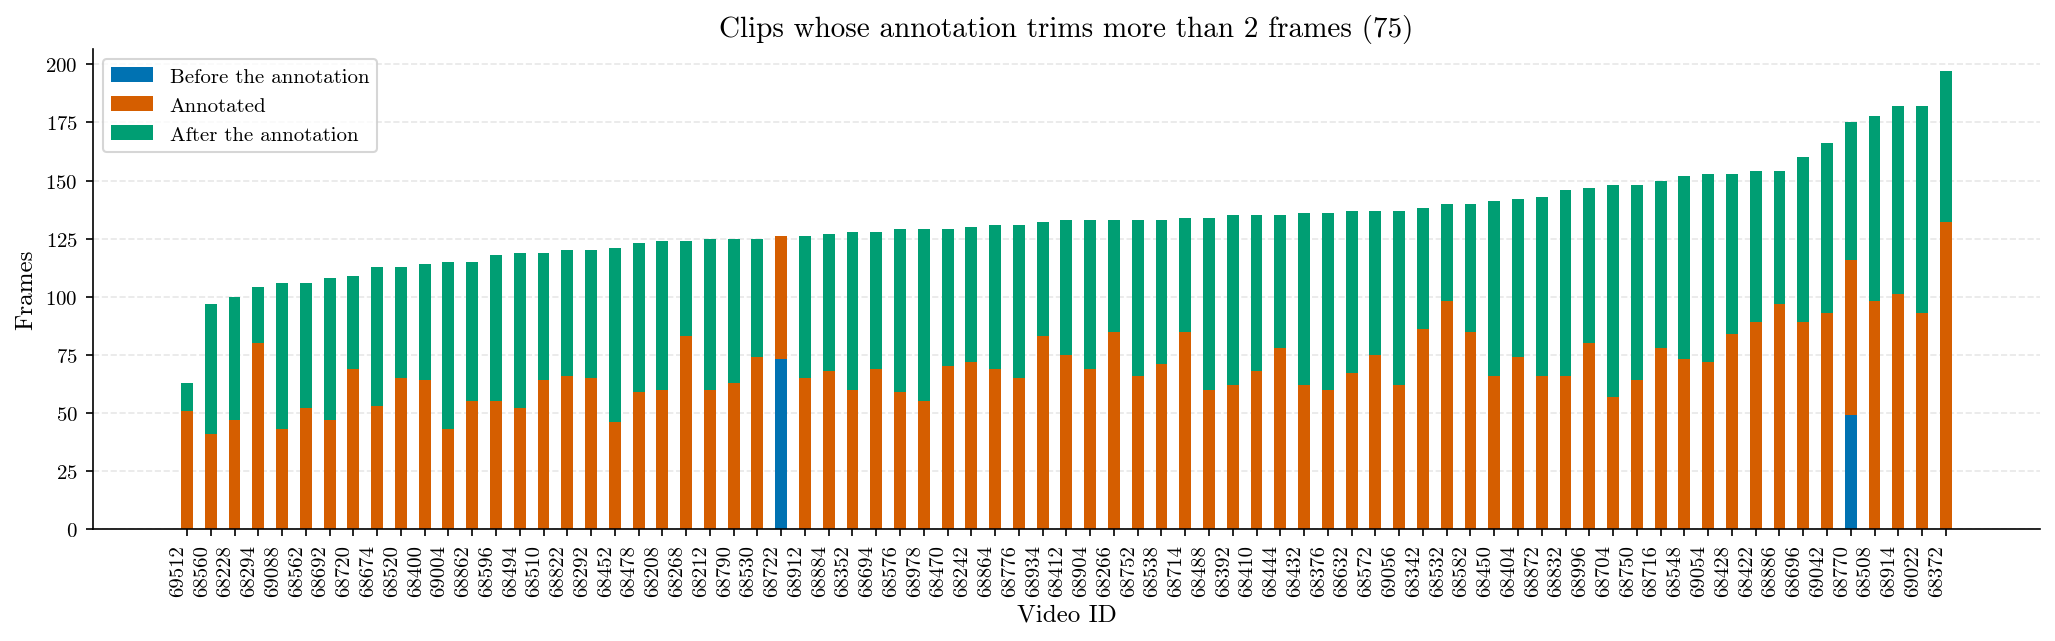

In [6]:
big_trims = trims[trims['trimmed'] > 2].sort_values('clip_frames')
fig, ax = plot_stacked_bar_chart(
    big_trims.index,
    {
        'before': big_trims['trimmed_start'],
        'annotated': big_trims['ann_end'] - big_trims['ann_start'],
        'after': big_trims['trimmed_end'],
    },
    legend_labels={'before': 'Before the annotation', 'annotated': 'Annotated', 'after': 'After the annotation'},
    title=f'Clips whose annotation trims more than 2 frames ({len(big_trims)})',
    xlabel='Video ID',
    ylabel='Frames',
    figsize=(FIGSIZE[0] * 2, FIGSIZE[1]),
    rotation=90,
    show_values=False,
)
ax.legend(loc='upper left')
big_trims['kept'] = 1 - big_trims['trimmed'] / big_trims['clip_frames']
print(f"Median fraction of the clip annotated: {big_trims['kept'].median():.2f}")

### Look at one trimmed clip

The frames the annotation cuts off, then the annotated ones. `68770` "now" trims both
ends.

"now" (lillybauer): annotated 49-116 of 175 frames


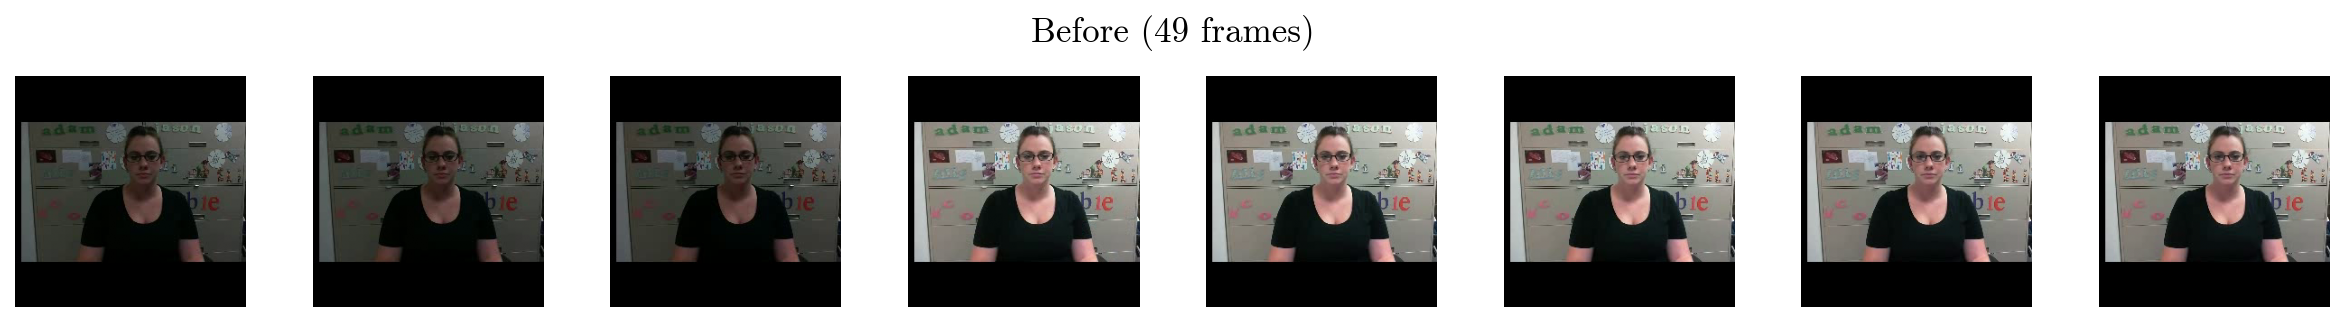

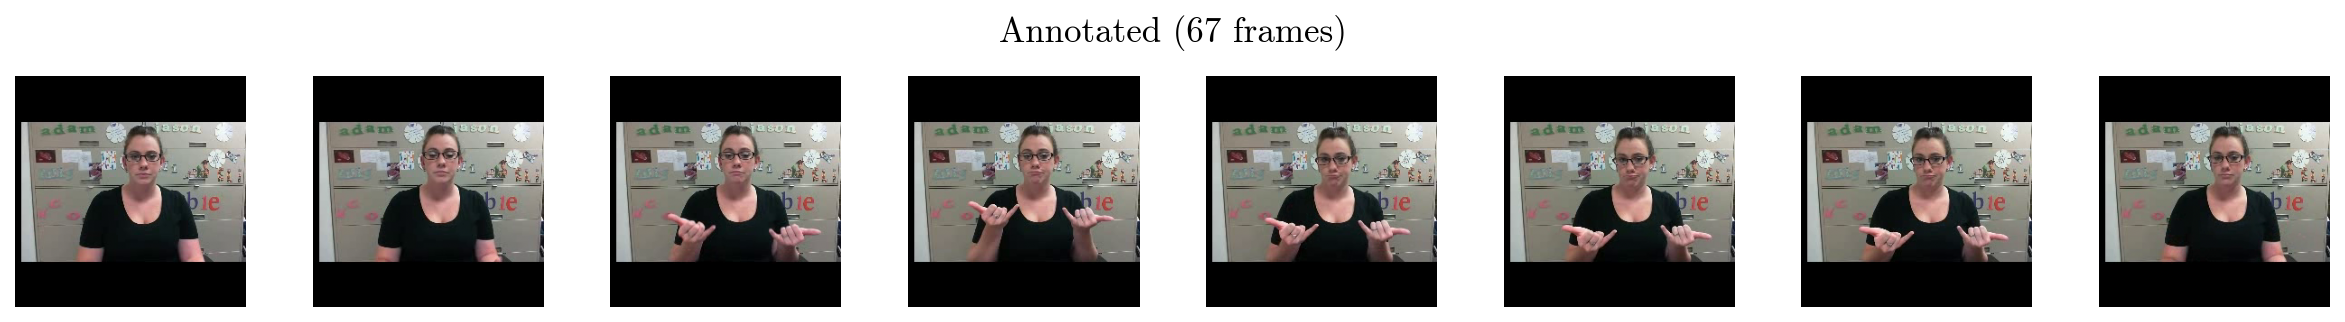

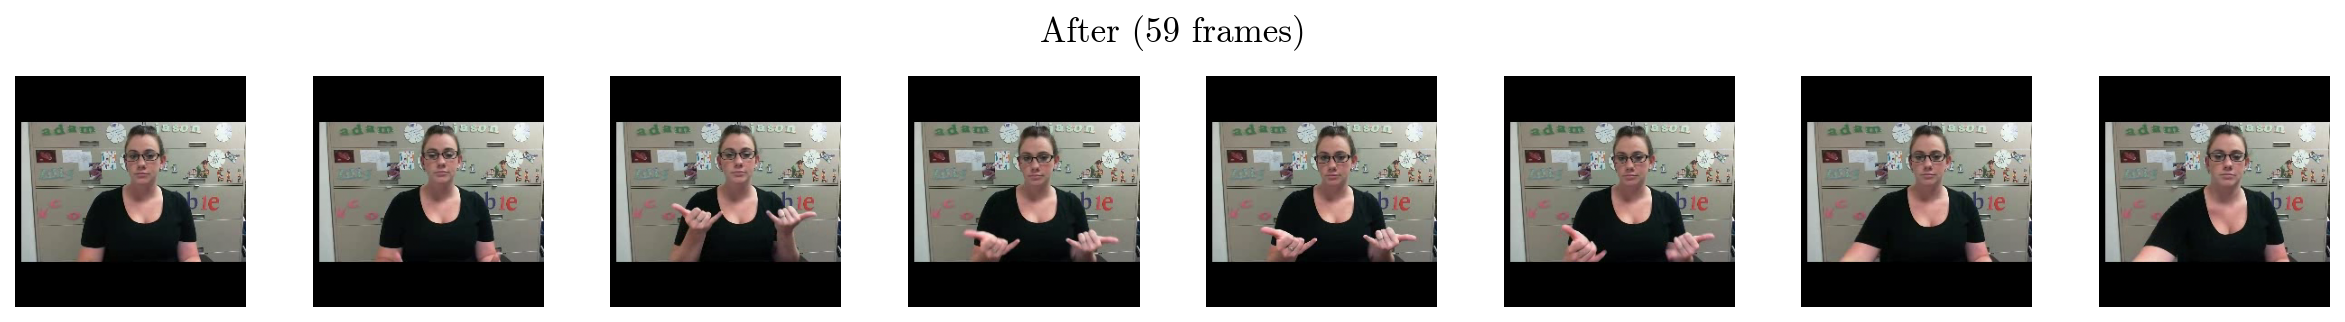

In [7]:
example_id = '68770'
example = ann_df.loc[example_id]
clip = load_rgb_frames_from_video(get_video_path(example_id, RAW_DIR), 0, 0, all=True)
start, end = int(example['ann_start']), int(example['ann_end'])
print(f'"{example["gloss"]}" ({example["source"]}): annotated {start}-{end} of {len(clip)} frames')
for name, part in [('before', clip[:start]), ('annotated', clip[start:end]), ('after', clip[end:])]:
    if len(part):
        plot_frame_grid(part, num=8, size=(2.0, 2.0), title=f'{name.capitalize()} ({len(part)} frames)')

The whole clip as a video, if `show_video`:

In [8]:
if show_video:
    display(animation_html(*animate_frames(clip, title=f'{example_id}: whole clip')))

## Labels vs annotations

What each label actually loads, compared with the annotated range:

* **matches annotation**: loads exactly the annotated frames.
* **skips first frame**: the label kept WLASL's 1-based start as a 0-based index (the
  off-by-one in labels made before cache version 2).
* **reset to whole clip**: the annotation was outside the clip.
* **other**: anything else. There should be none.

In [9]:
LabelKind: TypeAlias = Literal['matches annotation', 'skips first frame', 'reset to whole clip', 'other']

labels = [
    inst
    for set_name in set_names
    for inst in load_data_from_json(get_labels_path(set_name, labels_dir, LABEL_SUFFIX), 'strict')
    if isinstance(inst, Instance)
]
label_df = pd.DataFrame(
    {'label_start': [i.frame_start for i in labels], 'label_end': [i.frame_end for i in labels]},
    index=pd.Index([i.video_id for i in labels], name='video_id'),
).join(ann_df)


def label_kind(row: pd.Series) -> LabelKind:
    label, ann = (row['label_start'], row['label_end']), (row['ann_start'], row['ann_end'])
    if row['kind'] == 'outside clip':
        return 'reset to whole clip' if label == (0, row['clip_frames']) else 'other'
    if label == ann:
        return 'matches annotation'
    return 'skips first frame' if label == (ann[0] + 1, ann[1]) else 'other'


label_df['label_kind'] = label_df.apply(label_kind, axis=1)
label_df['label_frames'] = label_df['label_end'] - label_df['label_start']
label_df['ann_frames'] = (label_df['ann_end'] - label_df['ann_start']).where(label_df['kind'] != 'outside clip')
label_df['frames_lost'] = label_df['ann_frames'] - label_df['label_frames']

print(f'{len(labels)} labels for {len(ann_df)} annotations; missing: {sorted(set(ann_df.index) - set(label_df.index)) or "none"}')
print(f"Labels loading past the end of their clip: {(label_df['label_end'] > label_df['clip_frames']).sum()}")
label_df.groupby('label_kind').agg(
    instances=('label_kind', 'size'),
    whole_clip=('label_frames', lambda f: (f == label_df.loc[f.index, 'clip_frames']).sum()),
    frames_lost=('frames_lost', 'sum'),
).astype(int)

21095 labels for 21095 annotations; missing: none
Labels loading past the end of their clip: 0


,instances,whole_clip,frames_lost
label_kind,,,
matches annotation,20799,20718,0
reset to whole clip,296,296,0


`whole_clip` counts labels that load every frame of their clip, so would load the same
frames with no frame range at all. `frames_lost` is annotated frames the label doesn't
load (resets have no meaningful annotation, so count 0).

### Short clips

Clips of 10 or fewer frames, by what the label loads and by the annotation. A `*_cutoff_9`
split removes those whose label loads 9 or fewer.

In [10]:
short = label_df[(label_df['label_frames'] <= 10) | (label_df['ann_frames'] <= 10)]
short[['gloss', 'set', 'source', 'clip_frames', 'ann_frames', 'label_frames', 'label_kind']].sort_values('label_frames')

,gloss,set,source,clip_frames,ann_frames,label_frames,label_kind
video_id,,,,,,,
15144,deduct,val,handspeak,9,9.0,9,matches annotation
18223,earring,train,handspeak,10,10.0,10,matches annotation
59958,turkey,val,handspeak,10,10.0,10,matches annotation
